In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("adult.csv")
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()


age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
import numpy as np
for i in df.columns:
    df[i] = df[i].replace( '?',np.nan)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
cat=df.select_dtypes(include=['object']).columns
for i in cat:
    df[i]=le.fit_transform(df[i])
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,3,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,3,150601,0,6,5,0,4,4,1,0,3770,40,38,0
7,74,6,88638,10,16,4,9,2,4,0,0,3683,20,38,1
8,68,0,422013,11,9,0,9,1,4,0,0,3683,40,38,0
9,41,3,70037,15,10,4,2,4,4,1,0,3004,60,41,1


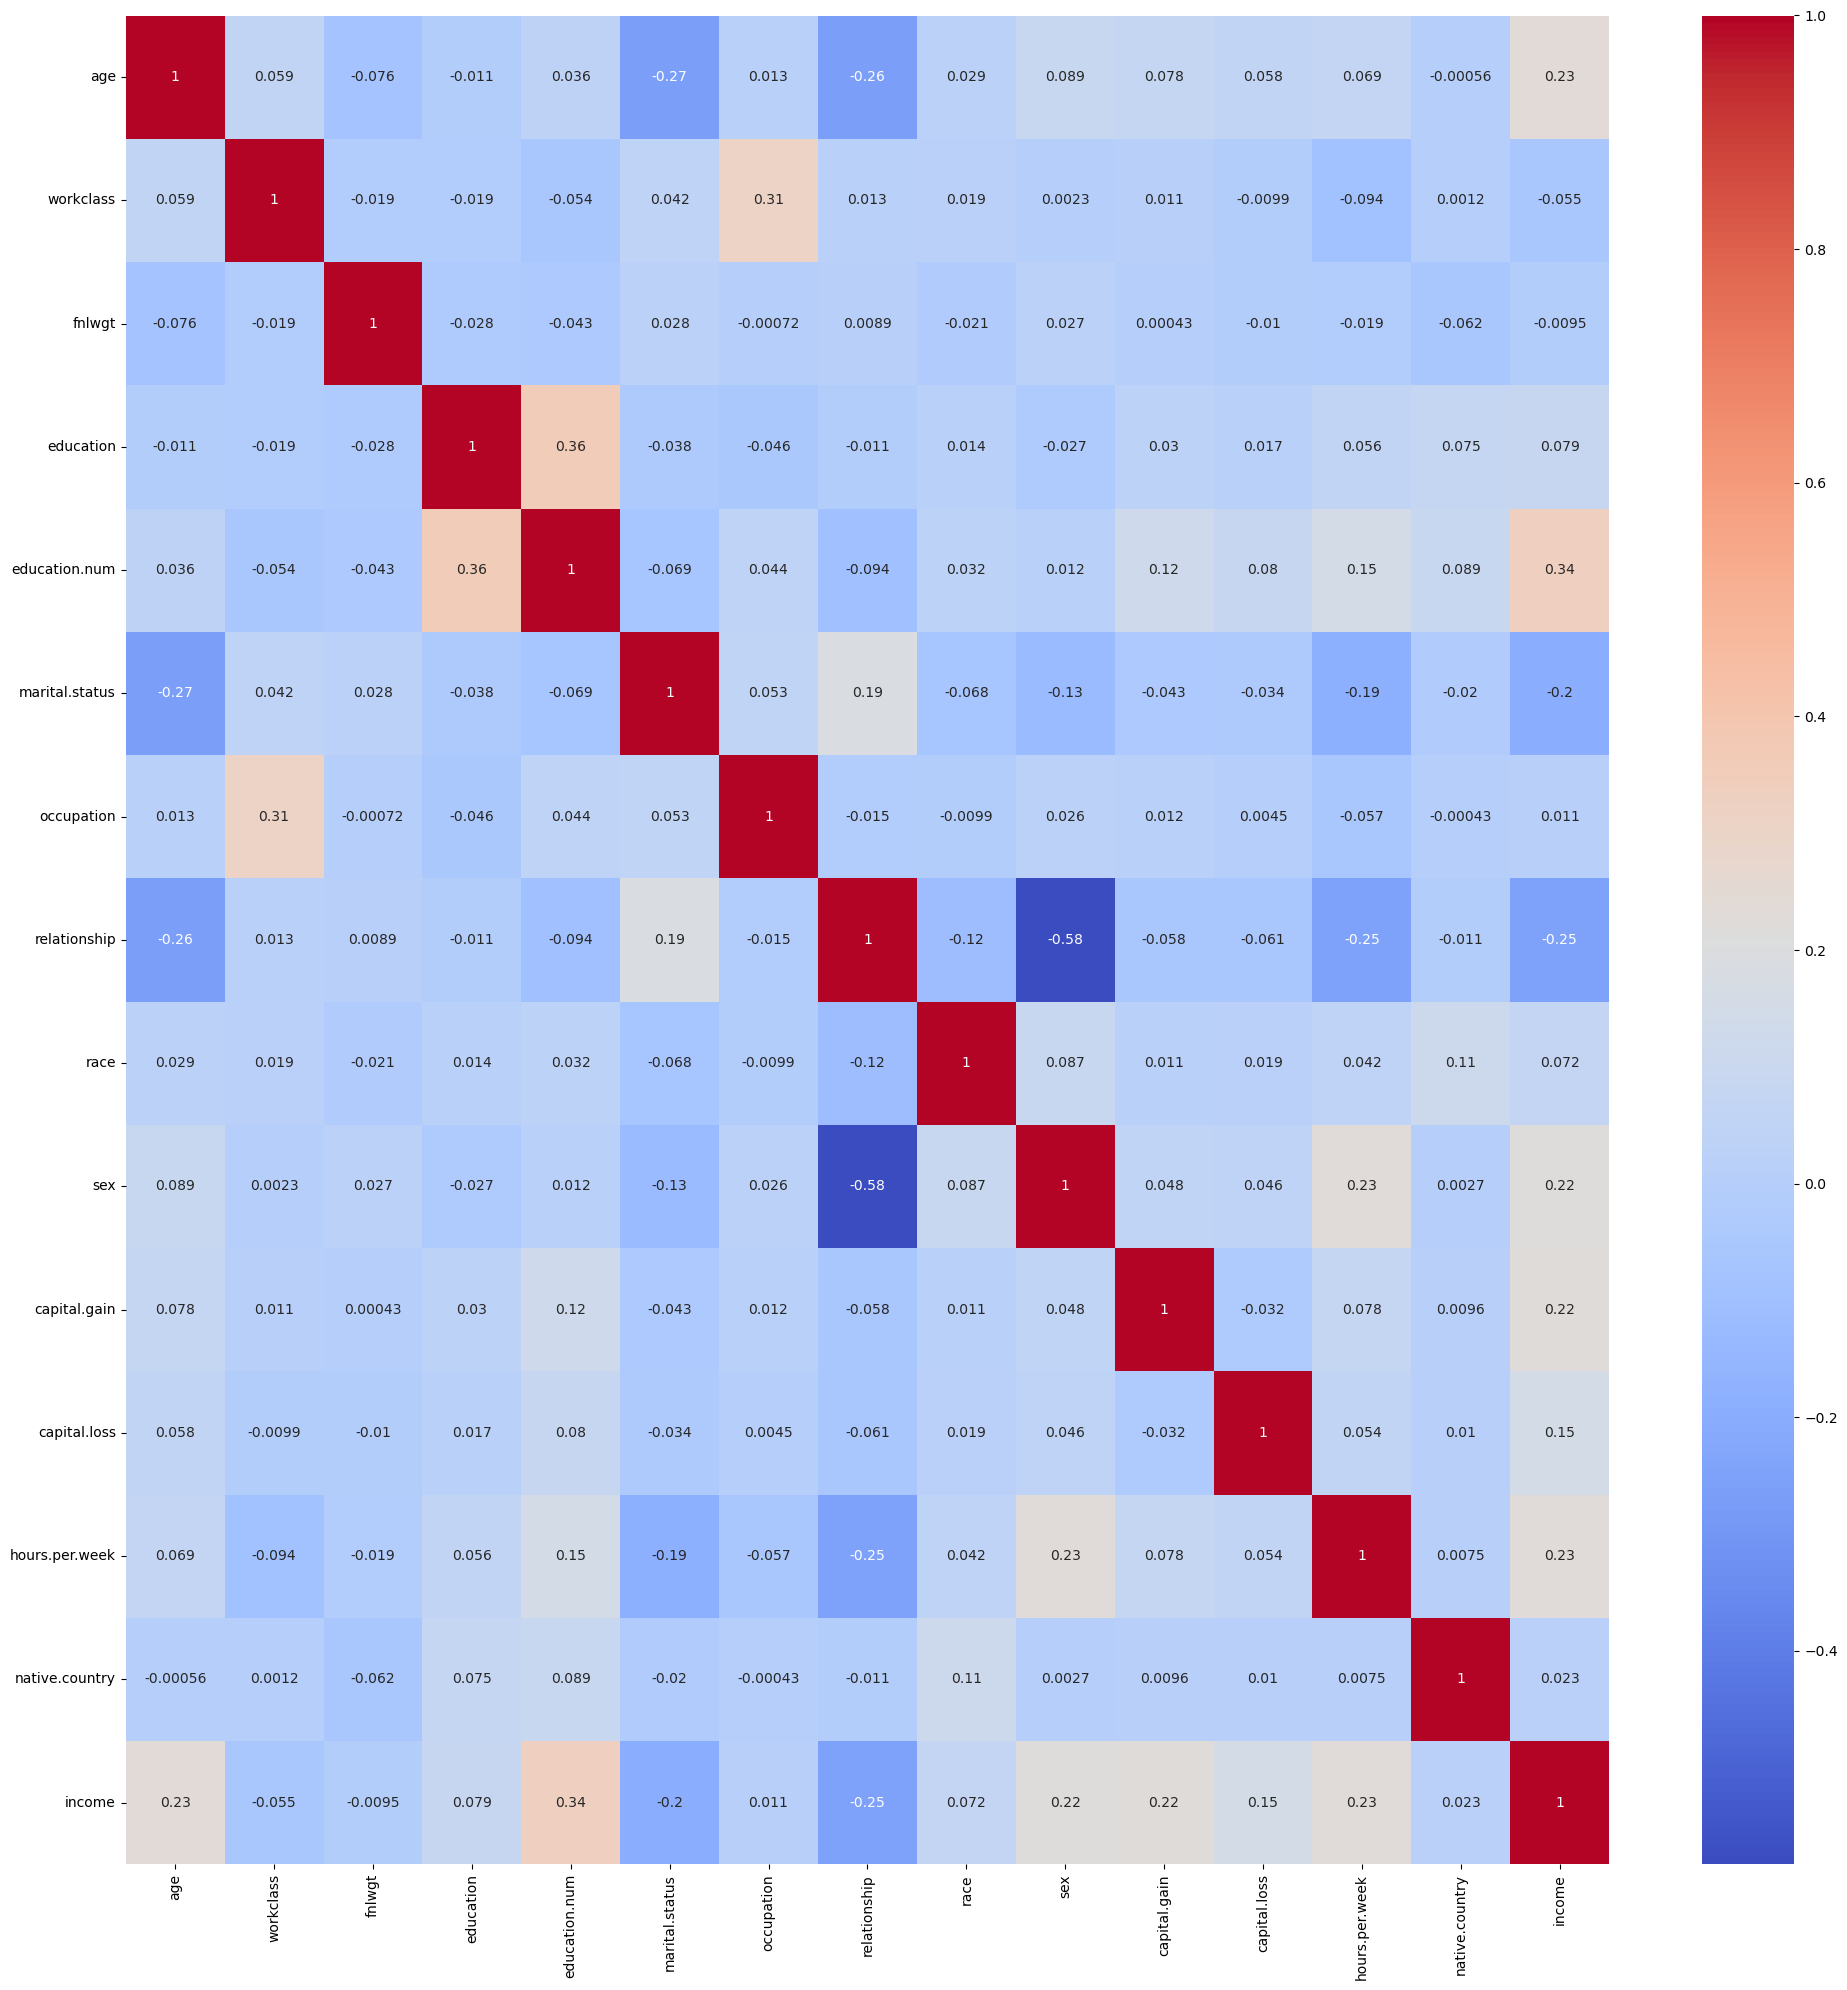

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr() , annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show();

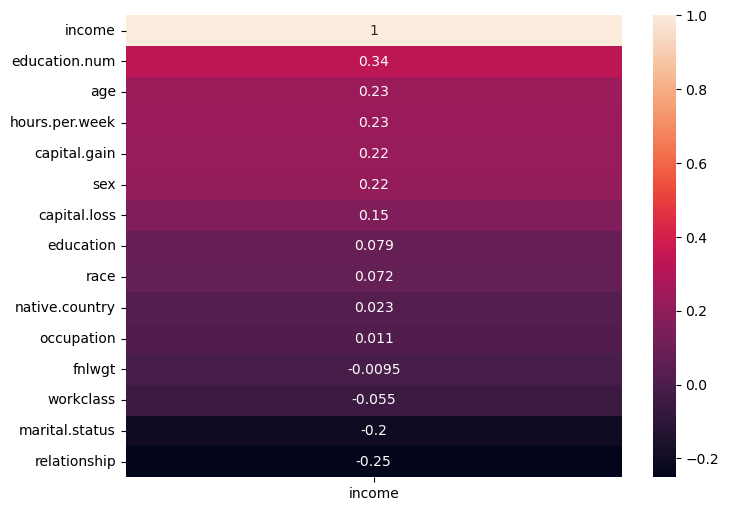

In [ ]:
corr = df.corr()
labeled_corr = corr[['income']].sort_values( 'income',ascending = False)

fig = plt.figure(figsize = (8,6))
sns.heatmap(labeled_corr,annot = True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
num=df.select_dtypes(include=['int64']).columns
for i in num:
    df[i]=sc.fit_transform(df[[i]])
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,1.000000,1.000,0.043987,0.733333,0.533333,1.000000,1.000000,0.2,1.0,0.0,0.0,1.000000,0.397959,0.926829,0.0
1,0.890411,0.375,0.081896,0.733333,0.533333,1.000000,0.214286,0.2,1.0,0.0,0.0,1.000000,0.173469,0.926829,0.0
2,0.671233,1.000,0.118021,1.000000,0.600000,1.000000,1.000000,0.8,0.5,0.0,0.0,1.000000,0.397959,0.926829,0.0
3,0.506849,0.375,0.086982,0.333333,0.200000,0.000000,0.428571,0.8,1.0,0.0,0.0,0.895317,0.397959,0.926829,0.0
4,0.328767,0.375,0.171404,1.000000,0.600000,0.833333,0.642857,0.6,1.0,0.0,0.0,0.895317,0.397959,0.926829,0.0
5,0.232877,0.375,0.138941,0.733333,0.533333,0.000000,0.500000,0.8,1.0,0.0,0.0,0.865473,0.448980,0.926829,0.0
6,0.287671,0.375,0.093938,0.000000,0.333333,0.833333,0.000000,0.8,1.0,1.0,0.0,0.865473,0.397959,0.926829,0.0
7,0.780822,0.750,0.051855,0.666667,1.000000,0.666667,0.642857,0.4,1.0,0.0,0.0,0.845500,0.193878,0.926829,1.0
8,0.698630,0.000,0.278268,0.733333,0.533333,0.000000,0.642857,0.2,1.0,0.0,0.0,0.845500,0.397959,0.926829,0.0
9,0.328767,0.375,0.039223,1.000000,0.600000,0.666667,0.142857,0.8,1.0,1.0,0.0,0.689624,0.602041,1.000000,1.0


In [ ]:
def remove_outliers(df, columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df


In [ ]:

def get_outlier_bounds(df, columns):
    bounds = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (q1 - 1.5*iqr, q3 + 1.5*iqr)
    return bounds

def apply_capping(df, bounds):
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
    return df

In [ ]:
def get_outlier_bounds(df, columns):
    bounds = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = (lower, upper)
    return bounds


def remove_outliers(df, bounds):
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop("income",axis=1)
y = df["income"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(y_test.value_counts())
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
acc=accuracy_score(y_test,y_pred)
print()
acc

income
0.0    4988
1.0    1520
Name: count, dtype: int64
              precision    recall  f1-score   support

         0.0       0.95      0.81      0.87      4988
         1.0       0.58      0.85      0.69      1520

    accuracy                           0.82      6508
   macro avg       0.76      0.83      0.78      6508
weighted avg       0.86      0.82      0.83      6508

[[4045  943]
 [ 223 1297]]



0.8208358942839582

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

def find_best_k(X_train, X_test, y_train, y_test, k_range=range(1,31)):
    acc = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        acc.append(accuracy_score(y_test, pred))

    best_k = k_range[acc.index(max(acc))]

    print(f"Best K = {best_k}")
    print(f"Accuracy = {max(acc):.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(list(k_range), acc, marker='o')
    plt.xlabel("K")
    plt.ylabel("Accuracy")
    plt.title("K vs Accuracy")
    plt.grid(True)
    plt.show()

    return best_k

Best K = 20
Accuracy = 0.8382


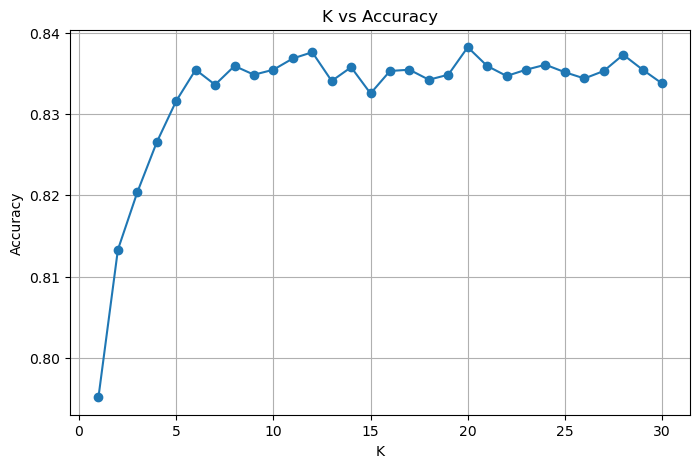

Accuracy: 0.83819913952059

Confusion Matrix:
[[4612  376]
 [ 677  843]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.90      4988
         1.0       0.69      0.55      0.62      1520

    accuracy                           0.84      6508
   macro avg       0.78      0.74      0.76      6508
weighted avg       0.83      0.84      0.83      6508



In [ ]:
X= df.drop("income",axis=1)
y = df["income"]
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)
# Train KNN
knn = KNeighborsClassifier(n_neighbors=find_best_k(X_train,X_test,y_train,y_test))
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


model = grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1: 0.6694418891495314


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred2 = model.predict(X_train)
accuracy = accuracy_score(y_test,y_pred)
accuracy2 = accuracy_score(y_train,y_pred2)
print(classification_report(y_test, y_pred) )
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')


              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88      4988
         1.0       0.60      0.62      0.61      1520

    accuracy                           0.81      6508
   macro avg       0.74      0.75      0.74      6508
weighted avg       0.82      0.81      0.82      6508

Precision: 0.8170078846040953
Recall: 0.8143822987092809


In [ ]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train,y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
y_pred2 = model.predict(X_train)
accuracy = accuracy_score(y_test,y_pred)
accuracy2 = accuracy_score(y_train,y_pred2)
print(f'Accuracy_test : {accuracy}\n Accurecy_train :{accuracy2}')
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


Accuracy_test : 0.7658266748617086
 Accurecy_train :0.7666833147643014
Precision: 0.8199846621642498
Recall: 0.7658266748617086
[[3805 1183]
 [ 341 1179]]
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83      4988
         1.0       0.50      0.78      0.61      1520

    accuracy                           0.77      6508
   macro avg       0.71      0.77      0.72      6508
weighted avg       0.82      0.77      0.78      6508

